[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/zhubarb/sesen_ai_ml_tutorials/blob/main/notebooks/bayesian/bayesian_inference.ipynb)

# From MLE to Bayesian Inference: Why Your Estimate Needs a Prior

This notebook accompanies the [blog post](https://www.sesen.ai/blog/from-mle-to-bayesian-inference) on sesen.ai.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

## Quick Win: A Coin Flip with a Prior

In the [MLE tutorial](https://www.sesen.ai/blog/maximum-likelihood-estimation-from-scratch), we estimated a coin's bias by finding the single parameter value that maximises the likelihood. Flip a coin 3 times, get 3 heads, and MLE says $\hat{\theta} = 1.0$ — the coin always lands heads. That feels wrong.

The problem isn't the likelihood — it's that MLE gives you a **point estimate** with no way to express doubt. Bayesian inference fixes this by computing an entire **distribution** over parameter values.

Let's revisit the coin flip, but this time with a **prior belief**. We'll use a $\text{Beta}(2, 2)$ prior — a mild belief the coin is roughly fair — and observe 7 heads in 10 flips.

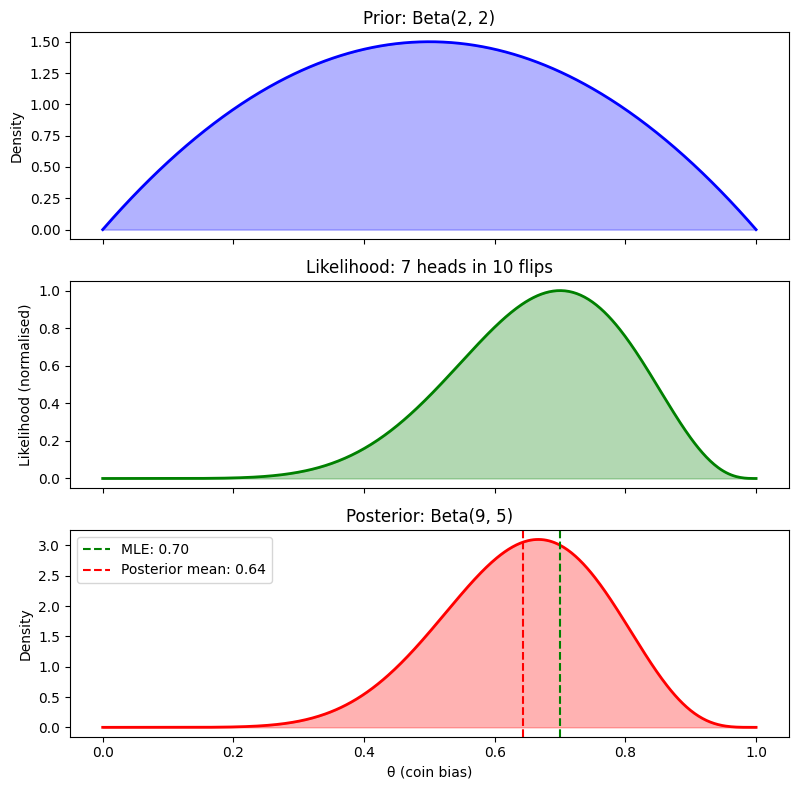

In [2]:
# Prior: Beta(2, 2) — mild belief the coin is roughly fair
alpha_prior, beta_prior = 2, 2

# Data: 7 heads out of 10 flips
z, N = 7, 10

# Posterior: Beta(alpha + z, beta + N - z)
alpha_post = alpha_prior + z
beta_post = beta_prior + (N - z)

# Plot prior, likelihood, and posterior
theta = np.linspace(0, 1, 500)
prior = stats.beta.pdf(theta, alpha_prior, beta_prior)
likelihood = theta**z * (1 - theta)**(N - z)
likelihood /= likelihood.max()  # normalise for plotting
posterior = stats.beta.pdf(theta, alpha_post, beta_post)

fig, axes = plt.subplots(3, 1, figsize=(8, 8), sharex=True)

axes[0].fill_between(theta, prior, alpha=0.3, color='blue')
axes[0].plot(theta, prior, 'b-', linewidth=2)
axes[0].set_ylabel('Density')
axes[0].set_title('Prior: Beta(2, 2)')

axes[1].fill_between(theta, likelihood, alpha=0.3, color='green')
axes[1].plot(theta, likelihood, 'g-', linewidth=2)
axes[1].set_ylabel('Likelihood (normalised)')
axes[1].set_title(f'Likelihood: {z} heads in {N} flips')

axes[2].fill_between(theta, posterior, alpha=0.3, color='red')
axes[2].plot(theta, posterior, 'r-', linewidth=2)
axes[2].axvline(z/N, color='green', linestyle='--', label=f'MLE: {z/N:.2f}')
axes[2].axvline(alpha_post/(alpha_post + beta_post), color='red', linestyle='--',
                label=f'Posterior mean: {alpha_post/(alpha_post + beta_post):.2f}')
axes[2].set_xlabel('\u03b8 (coin bias)')
axes[2].set_ylabel('Density')
axes[2].set_title(f'Posterior: Beta({alpha_post}, {beta_post})')
axes[2].legend()

plt.tight_layout()
plt.show()

In [3]:
print(f"MLE:            \u03b8 = {z/N:.3f}")
print(f"Posterior mean:  \u03b8 = {alpha_post/(alpha_post + beta_post):.3f}")
print(f"95% credible interval: [{stats.beta.ppf(0.025, alpha_post, beta_post):.3f}, "
      f"{stats.beta.ppf(0.975, alpha_post, beta_post):.3f}]")

MLE:            θ = 0.700
Posterior mean:  θ = 0.643
95% credible interval: [0.386, 0.861]


Notice two things the MLE can't give you:
1. **The posterior mean (0.643)** is pulled toward 0.5 compared to the MLE (0.700), because the prior nudges us toward fairness.
2. **The 95% credible interval** tells you exactly where the true bias probably lies — no bootstrapping or asymptotic arguments needed.

## Bayes' Rule: The One Equation

Everything in Bayesian inference flows from a single equation:

$$
p(\theta \mid D) = \frac{p(D \mid \theta) \; p(\theta)}{p(D)}
$$

Each term has a name:

| Term | Name | What it means |
|------|------|---------------|
| $p(\theta \mid D)$ | **Posterior** | What we believe about $\theta$ *after* seeing data |
| $p(D \mid \theta)$ | **Likelihood** | How probable is this data for a given $\theta$ |
| $p(\theta)$ | **Prior** | What we believed about $\theta$ *before* seeing data |
| $p(D)$ | **Evidence** | The total probability of the data across all $\theta$ values |

**MLE** treats $p(\theta)/p(D)$ as a constant and seeks a single point $\hat{\theta}$ that maximises the likelihood. **Bayesian estimation** fully calculates the posterior $p(\theta \mid D)$, treating $\theta$ as a random variable. We put in probability density functions and get out probability density functions — not a single point.

### The Evidence (Marginal Likelihood)

The denominator $p(D)$ ensures the posterior integrates to 1:

$$
p(D) = \int p(D \mid \theta) \; p(\theta) \; d\theta
$$

This integral sums the likelihood over *all* possible parameter values, weighted by the prior. For most models, this integral has no closed-form solution — which is exactly why methods like MCMC sampling exist. But for some lucky combinations of prior and likelihood, the integral works out analytically. These are called **conjugate priors**.

## The Disease Diagnosis Surprise

Before diving into conjugate priors, here's why priors matter so much — even with excellent data. This example, from Kruschke (2015), is one of the most counterintuitive results in all of probability.

Suppose a disease affects **1 in 1,000 people**. A diagnostic test has:
- **99% hit rate**: if you have the disease, the test is positive 99% of the time
- **5% false alarm rate**: if you're healthy, the test is still positive 5% of the time

You test positive. What's the probability you actually have the disease?

In [4]:
# Prior: base rate of the disease
p_disease = 0.001
p_healthy = 1 - p_disease

# Likelihood: test characteristics
p_positive_given_disease = 0.99   # hit rate
p_positive_given_healthy = 0.05   # false alarm rate

# Evidence: total probability of testing positive
p_positive = (p_positive_given_disease * p_disease +
              p_positive_given_healthy * p_healthy)

# Posterior: Bayes' Rule
p_disease_given_positive = (p_positive_given_disease * p_disease) / p_positive

print(f"Prior probability of disease:  {p_disease:.4f} ({p_disease*100:.1f}%)")
print(f"Posterior after positive test:  {p_disease_given_positive:.4f} "
      f"({p_disease_given_positive*100:.1f}%)")

Prior probability of disease:  0.0010 (0.1%)
Posterior after positive test:  0.0194 (1.9%)


**Only ~1.9%.** Despite the 99% hit rate, you almost certainly don't have the disease. Why? Because the disease is so rare (prior = 0.001) that the vast majority of positive results come from false alarms among healthy people.

This is Bayes' rule in action: the posterior depends on *both* the likelihood (test accuracy) and the prior (base rate). Ignoring the prior — as MLE effectively does — would lead to wildly overconfident conclusions.

## The Beta Distribution

For the Bernoulli/Binomial likelihood, the conjugate prior is the **Beta distribution**. It lives on $[0, 1]$ — perfect for modelling a probability parameter:

$$
\text{Beta}(\theta;\, \alpha, \beta) = \frac{\theta^{\alpha - 1}(1 - \theta)^{\beta - 1}}{B(\alpha, \beta)}
$$

where $B(\alpha, \beta)$ is the Beta function (a normalising constant). Think of $\alpha$ and $\beta$ as **pseudo-counts**: $\alpha - 1$ imaginary heads and $\beta - 1$ imaginary tails from a previous experiment. A flat $\text{Beta}(1, 1)$ means you've seen zero imaginary data — total ignorance.

The two parameters control the shape:

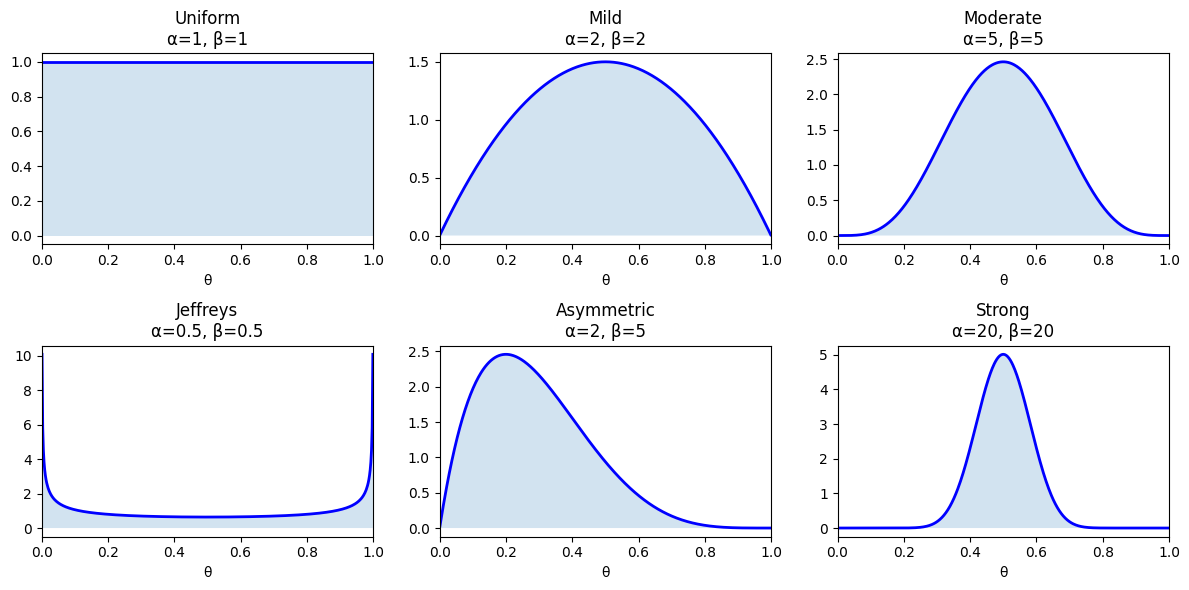

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(12, 6))

params = [(1, 1), (2, 2), (5, 5), (0.5, 0.5), (2, 5), (20, 20)]
titles = ['Uniform\n\u03b1=1, \u03b2=1', 'Mild\n\u03b1=2, \u03b2=2', 'Moderate\n\u03b1=5, \u03b2=5',
          'Jeffreys\n\u03b1=0.5, \u03b2=0.5', 'Asymmetric\n\u03b1=2, \u03b2=5', 'Strong\n\u03b1=20, \u03b2=20']

theta = np.linspace(0.001, 0.999, 500)
for ax, (a, b), title in zip(axes.flat, params, titles):
    ax.plot(theta, stats.beta.pdf(theta, a, b), 'b-', linewidth=2)
    ax.fill_between(theta, stats.beta.pdf(theta, a, b), alpha=0.2)
    ax.set_title(title)
    ax.set_xlabel('\u03b8')
    ax.set_xlim(0, 1)

plt.tight_layout()
plt.show()

## The Conjugate Update Rule

Here's the key result. If our prior is $\text{Beta}(\alpha, \beta)$ and we observe $z$ heads in $N$ flips, the posterior is:

$$
p(\theta \mid z, N) \propto \underbrace{\theta^z (1 - \theta)^{N-z}}_{\text{likelihood}} \times \underbrace{\theta^{\alpha - 1} (1 - \theta)^{\beta - 1}}_{\text{prior}}
$$

Combining the exponents:

$$
p(\theta \mid z, N) \propto \theta^{z + \alpha - 1} (1 - \theta)^{N - z + \beta - 1}
$$

This is another Beta distribution:

$$
\theta \mid z, N \;\sim\; \text{Beta}(\alpha + z, \;\; \beta + N - z)
$$

That's the entire update rule. The prior had $\alpha - 1$ pseudo-heads and $\beta - 1$ pseudo-tails. The data contributed $z$ real heads and $N - z$ real tails. The posterior simply adds them together.

### Summary Statistics

From the posterior $\text{Beta}(\alpha', \beta')$ where $\alpha' = \alpha + z$ and $\beta' = \beta + N - z$:

$$
\text{Posterior mean} = \frac{\alpha'}{\alpha' + \beta'} \qquad \text{MAP} = \frac{\alpha' - 1}{\alpha' + \beta' - 2}
$$

In [6]:
def bayesian_coin_summary(alpha_prior, beta_prior, z, N):
    """Posterior summary for the Beta-Binomial model."""
    alpha_post = alpha_prior + z
    beta_post = beta_prior + (N - z)

    posterior_mean = alpha_post / (alpha_post + beta_post)
    posterior_mode = (alpha_post - 1) / (alpha_post + beta_post - 2)
    mle = z / N
    ci_low = stats.beta.ppf(0.025, alpha_post, beta_post)
    ci_high = stats.beta.ppf(0.975, alpha_post, beta_post)

    print(f"Prior:           Beta({alpha_prior}, {beta_prior})")
    print(f"Data:            {z} heads in {N} flips")
    print(f"Posterior:       Beta({alpha_post}, {beta_post})")
    print(f"MLE:             {mle:.4f}")
    print(f"MAP estimate:    {posterior_mode:.4f}")
    print(f"Posterior mean:  {posterior_mean:.4f}")
    print(f"95% CI:          [{ci_low:.4f}, {ci_high:.4f}]")

# The coin from the MLE post: 73 heads in 100 flips
bayesian_coin_summary(2, 2, 73, 100)

Prior:           Beta(2, 2)
Data:            73 heads in 100 flips
Posterior:       Beta(75, 29)
MLE:             0.7300
MAP estimate:    0.7255
Posterior mean:  0.7212
95% CI:          [0.6316, 0.8027]


With 100 data points, the prior barely matters — the posterior mean is nearly identical to the MLE. The prior's influence fades as data accumulates.

## Prior vs. Data: More Data, Less Prior Influence

The posterior is always a compromise between the prior and the likelihood. With more data, the likelihood wins. Here we use a $\text{Beta}(10, 10)$ prior centred at 0.5 and observe 25% heads across increasing sample sizes.

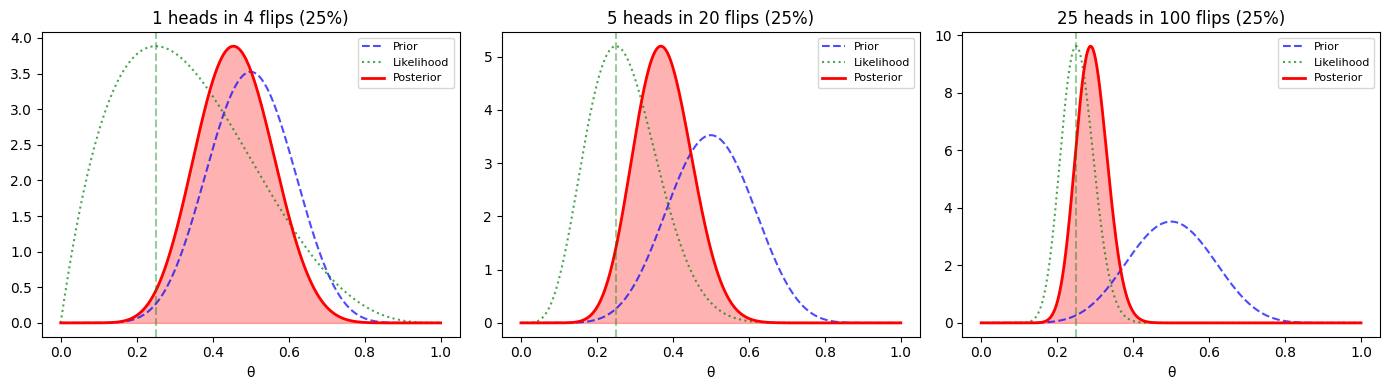

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
theta = np.linspace(0, 1, 500)
alpha_prior, beta_prior = 10, 10  # Prior centred at 0.5

for ax, (z, N) in zip(axes, [(1, 4), (5, 20), (25, 100)]):
    alpha_post = alpha_prior + z
    beta_post = beta_prior + (N - z)

    prior = stats.beta.pdf(theta, alpha_prior, beta_prior)
    posterior = stats.beta.pdf(theta, alpha_post, beta_post)
    likelihood = theta**z * (1 - theta)**(N - z)
    likelihood = likelihood / likelihood.max() * posterior.max()

    ax.plot(theta, prior, 'b--', linewidth=1.5, label='Prior', alpha=0.7)
    ax.plot(theta, likelihood, 'g:', linewidth=1.5, label='Likelihood', alpha=0.7)
    ax.fill_between(theta, posterior, alpha=0.3, color='red')
    ax.plot(theta, posterior, 'r-', linewidth=2, label='Posterior')
    ax.axvline(z/N, color='green', linestyle='--', alpha=0.4)
    ax.set_title(f'{z} heads in {N} flips (25%)')
    ax.set_xlabel('\u03b8')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

With 4 flips, the prior pulls the posterior toward 0.5. With 100 flips, the posterior clusters tightly around the MLE at 0.25. As Kruschke puts it: "The compromise favours the prior to the extent that the prior distribution is sharply peaked and the data are few."

## Prior vs. Data: Stronger Prior, More Resistance

A sharper prior requires more data to overcome. Here we fix the data at 3 heads in 10 flips and vary the prior strength from flat to strong.

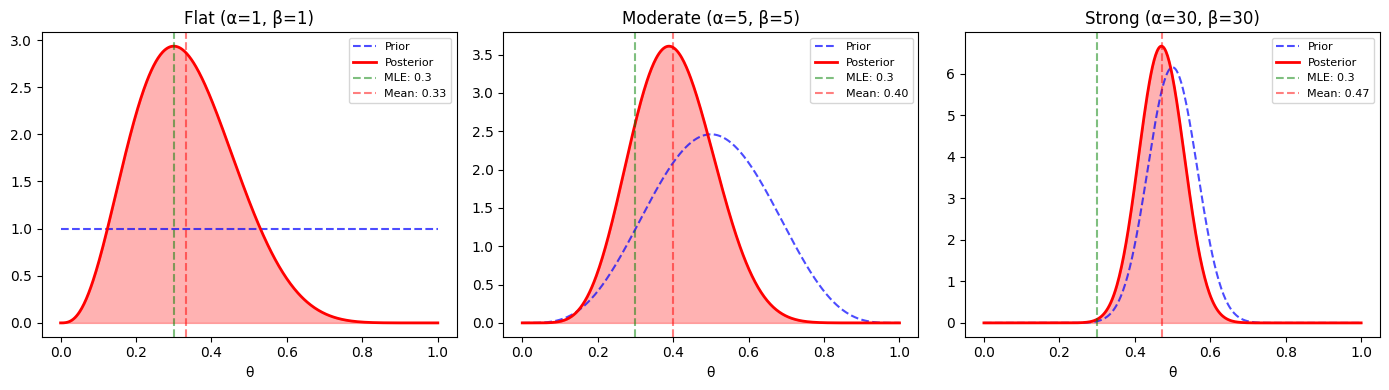

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
theta = np.linspace(0, 1, 500)
z, N = 3, 10

priors = [(1, 1, 'Flat (\u03b1=1, \u03b2=1)'),
          (5, 5, 'Moderate (\u03b1=5, \u03b2=5)'),
          (30, 30, 'Strong (\u03b1=30, \u03b2=30)')]

for ax, (a, b, title) in zip(axes, priors):
    alpha_post = a + z
    beta_post = b + (N - z)

    prior = stats.beta.pdf(theta, a, b)
    posterior = stats.beta.pdf(theta, alpha_post, beta_post)

    ax.plot(theta, prior, 'b--', linewidth=1.5, label='Prior', alpha=0.7)
    ax.fill_between(theta, posterior, alpha=0.3, color='red')
    ax.plot(theta, posterior, 'r-', linewidth=2, label='Posterior')
    ax.axvline(z/N, color='green', linestyle='--', alpha=0.5, label=f'MLE: {z/N:.1f}')
    mean = alpha_post / (alpha_post + beta_post)
    ax.axvline(mean, color='red', linestyle='--', alpha=0.5,
               label=f'Mean: {mean:.2f}')
    ax.set_title(title)
    ax.set_xlabel('\u03b8')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

With a flat prior, the posterior mode equals the MLE (0.30). With a strong prior centred at 0.5, ten flips barely move the posterior. This is rational: a sharp prior represents genuine previous knowledge that we'd be reluctant to abandon without overwhelming evidence.

## MLE as a Special Case of Bayesian Inference

When the prior is $\text{Beta}(1, 1)$ — the uniform distribution — the posterior mode (MAP estimate) simplifies to:

$$
\hat{\theta}_{\text{MAP}} = \frac{z}{N} = \hat{\theta}_{\text{MLE}}
$$

**MLE is just Bayesian inference with a uniform prior.** It's not "prior-free" — it implicitly assumes every parameter value is equally plausible before seeing data. When you use MLE, you *are* making a prior assumption, whether you realise it or not.

In [9]:
# Demonstrate that Beta(1,1) prior gives MAP = MLE
z, N = 7, 10
alpha_prior, beta_prior = 1, 1  # Uniform (flat) prior

alpha_post = alpha_prior + z
beta_post = beta_prior + (N - z)

mle = z / N
map_estimate = (alpha_post - 1) / (alpha_post + beta_post - 2)

print(f"Data: {z} heads in {N} flips")
print(f"Prior: Beta({alpha_prior}, {beta_prior}) — Uniform")
print(f"Posterior: Beta({alpha_post}, {beta_post})")
print(f"MLE:          {mle:.4f}")
print(f"MAP estimate: {map_estimate:.4f}")
print(f"MLE == MAP?   {np.isclose(mle, map_estimate)}")

Data: 7 heads in 10 flips
Prior: Beta(1, 1) — Uniform
Posterior: Beta(8, 4)
MLE:          0.7000
MAP estimate: 0.7000
MLE == MAP?   True


## Sequential Updating

One powerful property of Bayesian inference: you can update beliefs incrementally as new data arrives. Today's posterior becomes tomorrow's prior.

The order doesn't matter: updating with Batch 1 then Batch 2 gives the same posterior as Batch 2 then Batch 1, as long as the data are independent. This is **data-order invariance** (Kruschke, 2015, Section 5.2.1).

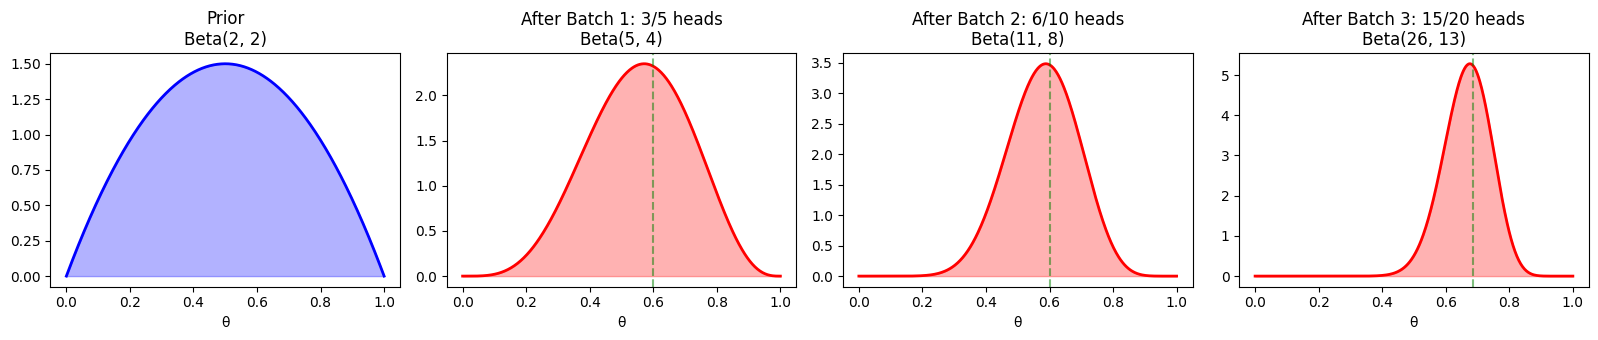

Final posterior: Beta(26, 13)
Posterior mean: 0.667
Total data: 24 heads in 35 flips


In [10]:
alpha, beta_param = 2, 2
theta = np.linspace(0, 1, 500)

batches = [(3, 5, 'Batch 1: 3/5 heads'),
           (6, 10, 'Batch 2: 6/10 heads'),
           (15, 20, 'Batch 3: 15/20 heads')]

fig, axes = plt.subplots(1, len(batches) + 1, figsize=(16, 3.5))

axes[0].fill_between(theta, stats.beta.pdf(theta, alpha, beta_param),
                     alpha=0.3, color='blue')
axes[0].plot(theta, stats.beta.pdf(theta, alpha, beta_param), 'b-', linewidth=2)
axes[0].set_title(f'Prior\nBeta({alpha}, {beta_param})')
axes[0].set_xlabel('\u03b8')

total_z, total_N = 0, 0
for i, (z_i, n_i, label) in enumerate(batches):
    alpha += z_i
    beta_param += (n_i - z_i)
    total_z += z_i
    total_N += n_i

    axes[i + 1].fill_between(theta, stats.beta.pdf(theta, alpha, beta_param),
                              alpha=0.3, color='red')
    axes[i + 1].plot(theta, stats.beta.pdf(theta, alpha, beta_param),
                     'r-', linewidth=2)
    axes[i + 1].axvline(total_z / total_N, color='green', linestyle='--', alpha=0.5)
    axes[i + 1].set_title(f'After {label}\nBeta({alpha}, {beta_param})')
    axes[i + 1].set_xlabel('\u03b8')

plt.tight_layout()
plt.show()

print(f"Final posterior: Beta({alpha}, {beta_param})")
print(f"Posterior mean: {alpha / (alpha + beta_param):.3f}")
print(f"Total data: {total_z} heads in {total_N} flips")

## Exercises

### 1. The Sunrise Problem
You've seen the sun rise every day of your life. Use Bayesian inference to compute the probability it rises tomorrow. How does your prior change the answer?

### 2. Normal-Normal Conjugacy
The Normal distribution is conjugate to itself. With known variance, derive the posterior for the mean given a Normal prior.

### 3. MAP vs. Posterior Mean
When do the MAP estimate and posterior mean disagree most? Create an example with a skewed Beta prior.

### 4. Drug Trial
A new drug cures 8 out of 10 patients. Your prior from previous studies is $\text{Beta}(3, 7)$ (30% success rate). What does the posterior tell you?

### 5. Breaking Conjugacy
Replace the Beta prior with a mixture of two Betas and show the posterior is no longer Beta. Approximate it using grid methods.